In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.summary_statistics.angular_correlation_function_wigner import AngularCorrelationFunctionWigner

import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

/Users/guadalupecanasherrera/miniforge3/envs/cloe-org-tensorflow-fix/lib/python3.10/site-packages/HMcode2020Emu
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


## Cosmology: Background and Perturbations

This code snippet initializes and computes the cosmological background and perturbations at various redshifts using the **CAMB** and **HMCode2020Emu** interfaces.

In [2]:
zs = np.linspace(1e-4, 3, 100)

# The arguments of the Background functions follow the cosmology.API
background = CAMBBackground(H0=70.0, 
                            Omega_cdm0=0.25, 
                            Omega_b0=0.05, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2e-9,
                            mnu = 0.06,
                            gamma_MG = 0.545,
                            N_mnu = 1)
linear_perturbations_emu = HMemuLinearPerturbations(background, zs)
nonlinear_perturbations_emu = HMemuNonLinearPerturbations(background, linear_perturbations_emu, zs, log10TAGN=7.8)

## Download and Read the Data

In this step, we use the `euclidlib` library to read the data, which follows . `euclidlib` provides the necessary functions and utilities to access and handle data from the Euclid mission, allowing us to seamlessly retrieve, process, and analyze the large datasets generated by the mission. 

For this tutorial, we use example synthetic data stored at https://zenodo.org/communities/cloe-org


In [3]:
# Execute this cell to download the data
data_downloaded = True

if data_downloaded == False:
    
    import requests
    
    # URLs of the files to be downloaded
    urls = {
        'nz_example.fits': 'https://zenodo.org/records/15092862/files/nz_example.fits',
        'mixmats_example.fits': 'https://zenodo.org/records/17191365/files/example-mixmats.fits',
        'cls_example.fits': 'https://zenodo.org/records/17191365/files/example-spectra.fits'
    }
    
    # Function to download a file
    def download_file(url, filename):
        response = requests.get(url)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
            print(f'{filename} downloaded successfully')
        else:
            print(f'Failed to download {filename}. Status code: {response.status_code}')
    
    # Download all files
    for filename, url in urls.items():
        download_file(url, filename)

In [4]:
# Read the data using euclidlib v2025.1
# Remember, only pip install euclidlib necessary!

z_nz, nz_example = el.photo.redshift_distributions('nz_example.fits')
cls_example = el.photo.angular_power_spectra('cls_example.fits')
mixmats_example = el.photo.mixing_matrices('mixmats_example.fits')

## Plot the galaxy redshift distribution $n(z)$

We use a synthetic galaxy redshift bin distribution that contains 6 redshift bins. We assume that both sources and lenses follow the same distributions.

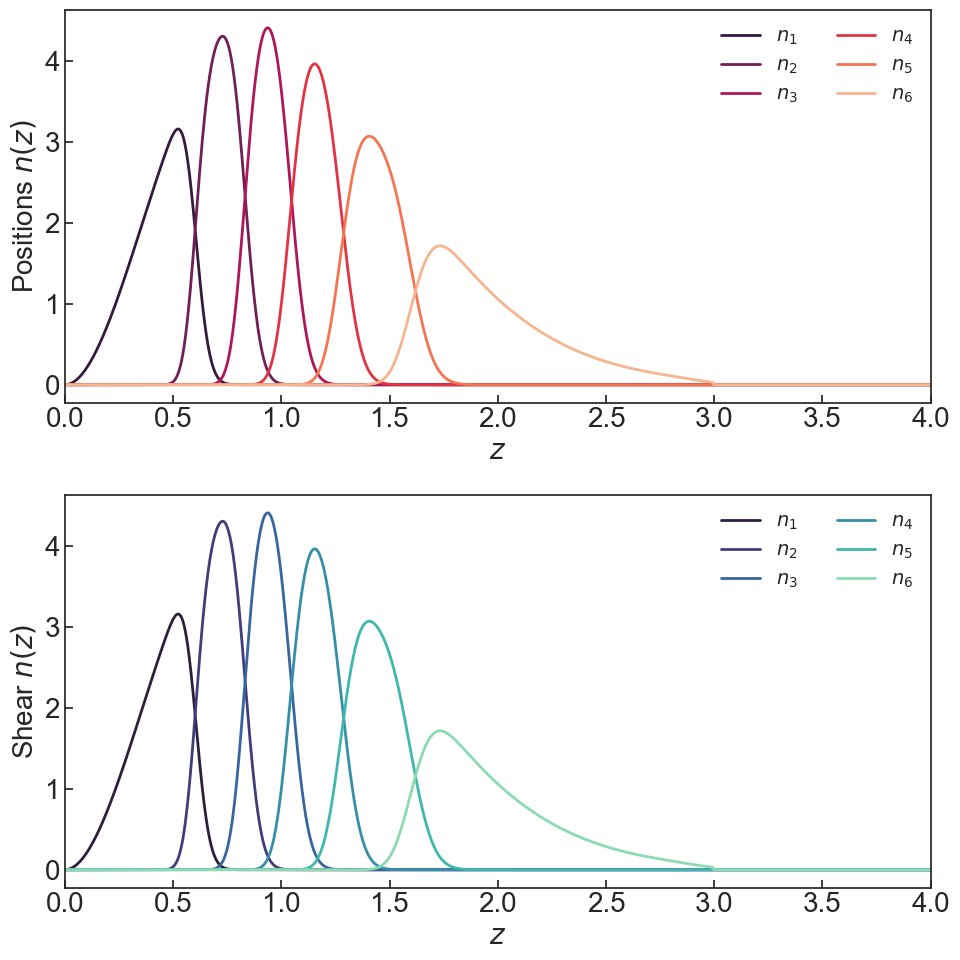

In [5]:
# Function to normalize dndz
def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized

# Normalize both dndz_pos and dndz_she
dndz_pos_norm = normalize_dndz(nz_example, z_nz)
dndz_she_norm = normalize_dndz(nz_example, z_nz)

# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values()))
    my_dndz_norm = np.zeros([len(nz_example), len(myz)])
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :])
    return my_dndz_norm

# Resampling the normalized dndz with 100 values
my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z_nz, zs)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z_nz, zs)

# Plotting dndz
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Customize tick parameters for both axes
for ax in axs.flatten():
    ax.tick_params(axis='both', which='both', direction='in')

# Plot positions n(z)
for i, (key, color) in enumerate(zip(dndz_pos_norm.keys(), sns.color_palette("rocket", len(dndz_pos_norm)))):
    axs[0].plot(z_nz, dndz_pos_norm[key], label=f'$n_{{{i+1}}}$', linewidth=2, color=color)

# Plot shear n(z)
for j, (key, color) in enumerate(zip(dndz_she_norm.keys(), sns.color_palette("mako", len(dndz_she_norm)))):
    axs[1].plot(z_nz, dndz_she_norm[key], label=f'$n_{{{j+1}}}$', linewidth=2, color=color)

# Set labels and legends
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$')
axs[0].set_xlim(0, 4)
axs[0].legend(frameon=False, ncol=2)

axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$')
axs[1].set_xlim(0, 4)
axs[1].legend(frameon=False, ncol=2)

plt.tight_layout()
plt.show()



## Observables: shear and position tracers 

We compute tracers (window functions) for both shear and galaxy positions observations, to be later combined in the computation of the summary statistics.

In [6]:
# Select the perturbations object you want to use
perturbations = nonlinear_perturbations_emu

# Define the tracers
tracer_pos = PositionsTracer(perturbations=perturbations, 
                             dndz=my_dndz_pos_norm,
                             z = zs,
                             galaxy_bias_model='poly',
                             nuisance_params={'b1_photo_poly0': 1.0, 'b1_photo_poly1': 0.0, 
                                              'b1_photo_poly2': 0.0, 'b1_photo_poly3': 0.0,
                                              'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
                                              'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
                                              'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
                                              'dz_pos_1': 0.0001, 'dz_pos_2': 0.0001,
                                              'dz_pos_3': 0.0001, 'dz_pos_4': 0.0001,
                                              'dz_pos_5': 0.0001, 'dz_pos_6': 0.0001})

tracer_she = ShearTracer(perturbations=perturbations, 
                             dndz=my_dndz_she_norm,
                             z = zs,
                             nuisance_params={'AIA': 1.72, 'CIA': 0.0134, 'EtaIA':-0.41,
                                              'multiplicative_bias_1': 0.001, 'multiplicative_bias_2': 0.001,
                                              'multiplicative_bias_3': 0.001, 'multiplicative_bias_4': 0.001,
                                              'multiplicative_bias_5': 0.001, 'multiplicative_bias_6': 0.001,
                                              'dz_shear_1': 0.0001, 'dz_shear_2': 0.0001,
                                              'dz_shear_3': 0.0001, 'dz_shear_4': 0.0001,
                                              'dz_shear_5': 0.0001, 'dz_shear_6': 0.0001})

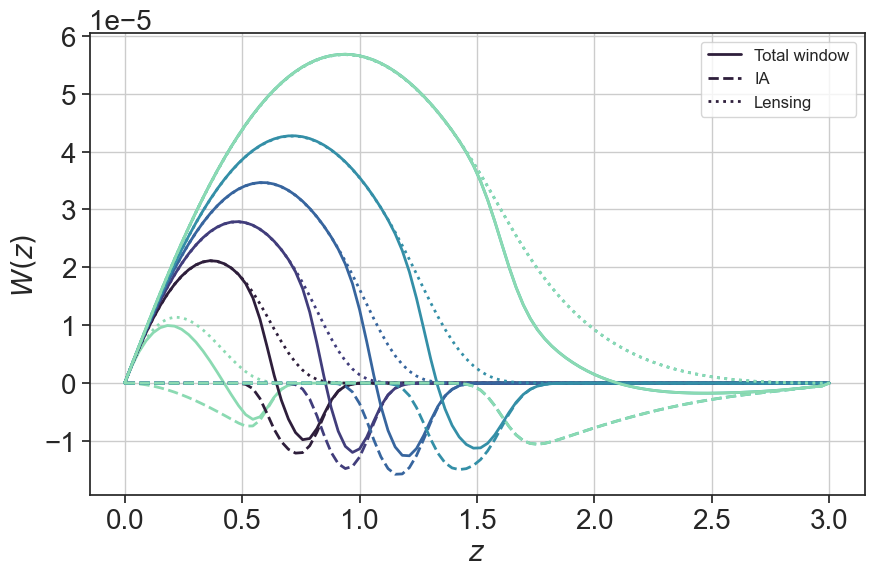

In [7]:
colors = sns.color_palette("mako", len(nz_example.keys()))

# Create the figure
plt.figure(figsize=(10, 6))

# Plot all three sets of data in one loop

for i in range(0, 7):
    # Plot the window
    plt.plot(perturbations.z, 
             tracer_she.get_window(perturbations.z)[i, :], 
             linewidth=2, 
             color=colors[i-1], 
             label=f'Total window' if i == 1 else "")
    
    # Plot the intrinsic alignment window
    plt.plot(perturbations.z, 
             tracer_she.get_window_IA(perturbations.z)[i, :], 
             linewidth=2, 
             linestyle='--', 
             color=colors[i-1], 
             label=f'IA' if i == 1 else "")
    
    # Plot the lensing window
    plt.plot(perturbations.z, 
             tracer_she.get_window_lensing(perturbations.z)[i, :], 
             linewidth=2, 
             linestyle=':', 
             color=colors[i-1], 
             label=f'Lensing' if i == 1 else "")

# Label the axes
plt.xlabel(r'$z$')
plt.ylabel(r'$W(z)$')

# Add the legend and grid
plt.legend(fontsize=12, loc='upper right')
plt.grid(True)

# Show the plot
plt.show()


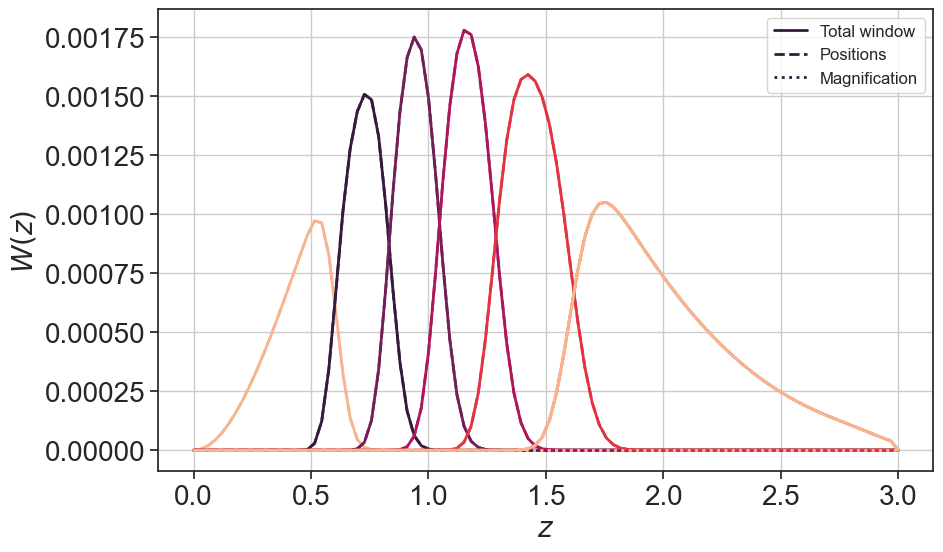

In [8]:
colors = sns.color_palette("rocket", len(nz_example.keys()))

# Create the figure
plt.figure(figsize=(10, 6))

# Plot all three sets of data in one loop

for i in range(0, 7):
    # Plot the window
    plt.plot(perturbations.z, 
             tracer_pos.get_window(perturbations.z)[i, :], 
             linewidth=2, 
             color=colors[i-1], 
             label=f'Total window' if i == 1 else "")
    
    # Plot the intrinsic alignment window
    plt.plot(perturbations.z, 
             tracer_pos.get_window_positions(perturbations.z)[i, :], 
             linewidth=2, 
             linestyle='--', 
             color=colors[i-1], 
             label=f'Positions' if i == 1 else "")
    
    # Plot the lensing window
    plt.plot(perturbations.z, 
             tracer_pos.get_window_magnification(perturbations.z)[i, :], 
             linewidth=2, 
             linestyle=':', 
             color=colors[i-1], 
             label=f'Magnification' if i == 1 else "")

# Label the axes
plt.xlabel(r'$z$')
plt.ylabel(r'$W(z)$')

# Add the legend and grid
plt.legend(fontsize=12, loc='upper right')
plt.grid(True)

# Show the plot
plt.show()

## Angular power spectra

### Theoretical Predictions: $C_\ell$

We compute angular power spectra initialising the corresponding `cloelib` class. First, we plot the $C_\ell$ without the convolution with the mixing matrices.

In [9]:
nl = 100
ells = np.logspace(1., np.log10(3000), nl)

twopoint_pospos = AngularTwoPoint(tracer_pos, tracer_pos)
twopoint_shepos = AngularTwoPoint(tracer_she, tracer_pos)
twopoint_posshe = AngularTwoPoint(tracer_pos, tracer_she)
twopoint_sheshe = AngularTwoPoint(tracer_she, tracer_she)

cells ={**twopoint_pospos.get_Cl(ells, 0, perturbations.k)
, **twopoint_shepos.get_Cl(ells, 0, perturbations.k)
, **twopoint_sheshe.get_Cl(ells, 0, perturbations.k)}

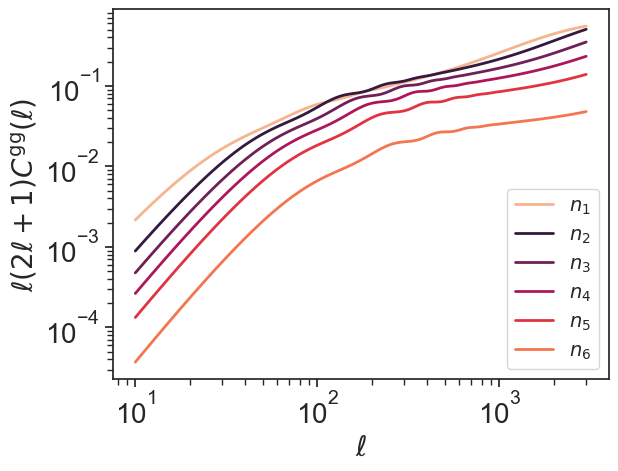

In [10]:
for i in range(0, 6):
    plt.loglog(ells, ells*(2*ells+1)*cells['POS', 'POS', i+1, i+1].array, label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(nz_example.keys()))[i-1])
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm gg}(\ell)$');
plt.legend(fontsize=14);

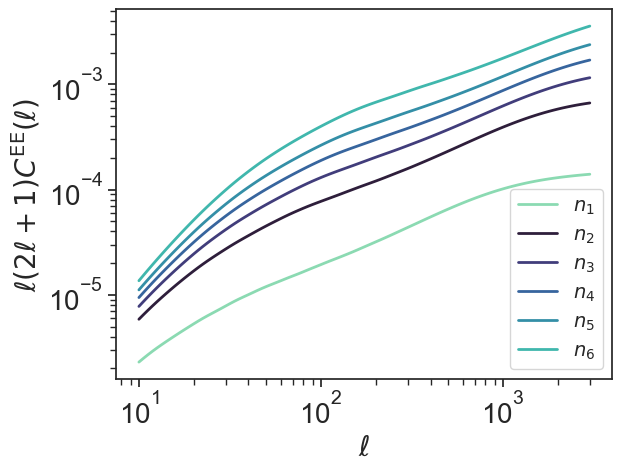

In [11]:
for i in range(0, 6):
    plt.loglog(ells, ells*(2*ells+1)*cells['SHE', 'SHE', i+1, i+1].array[0, 0], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("mako", len(nz_example.keys()))[i-1])
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm EE}(\ell)$');
plt.legend(fontsize=14);

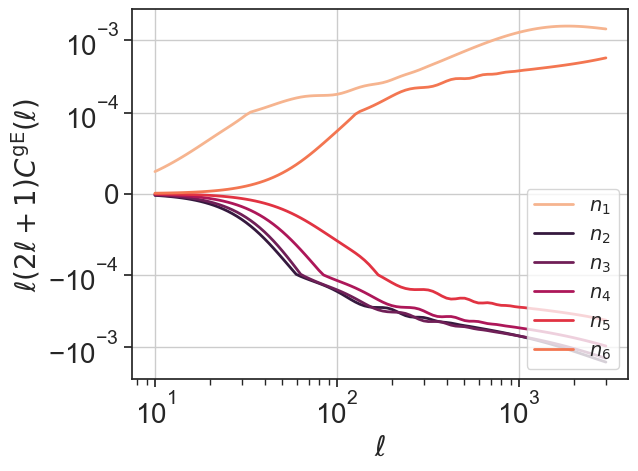

In [12]:
for i in range(0, 6):
    ells = cells['POS', 'SHE', i+1, i+1].ell
    plt.loglog(ells, ells*(2*ells+1)*cells['POS', 'SHE', i+1, i+1][0], label = '$n_{{{}}}$'.format(i+1), linewidth=2, color=sns.color_palette("rocket", len(nz_example.keys()))[i-1])

# Labels and legend
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\ell (2\ell +1)C^{\rm gE}(\ell)$')
plt.legend(fontsize=14, loc=4)

# Set y-axis to symmetric log scale to handle negative values
plt.yscale('symlog', linthresh=1e-4)
plt.xscale('log')
# Show the grid and the plot
plt.grid(True)
plt.show()

### Theoretical Predictions: pseudo-$C_\ell$

Second, we plot the $C_\ell$ with the convolution with the mixing matrices. 

In [13]:
ell_cell = mixmats_example[('POS', 'POS', 1, 1)].ell

In [14]:
cells_PP = twopoint_pospos.get_pseudo_Cl(0, perturbations.k,mixmats_example)
cells_SS = twopoint_sheshe.get_pseudo_Cl(nl, perturbations.k,mixmats_example)
cells_PS = twopoint_shepos.get_pseudo_Cl(nl, perturbations.k,mixmats_example)

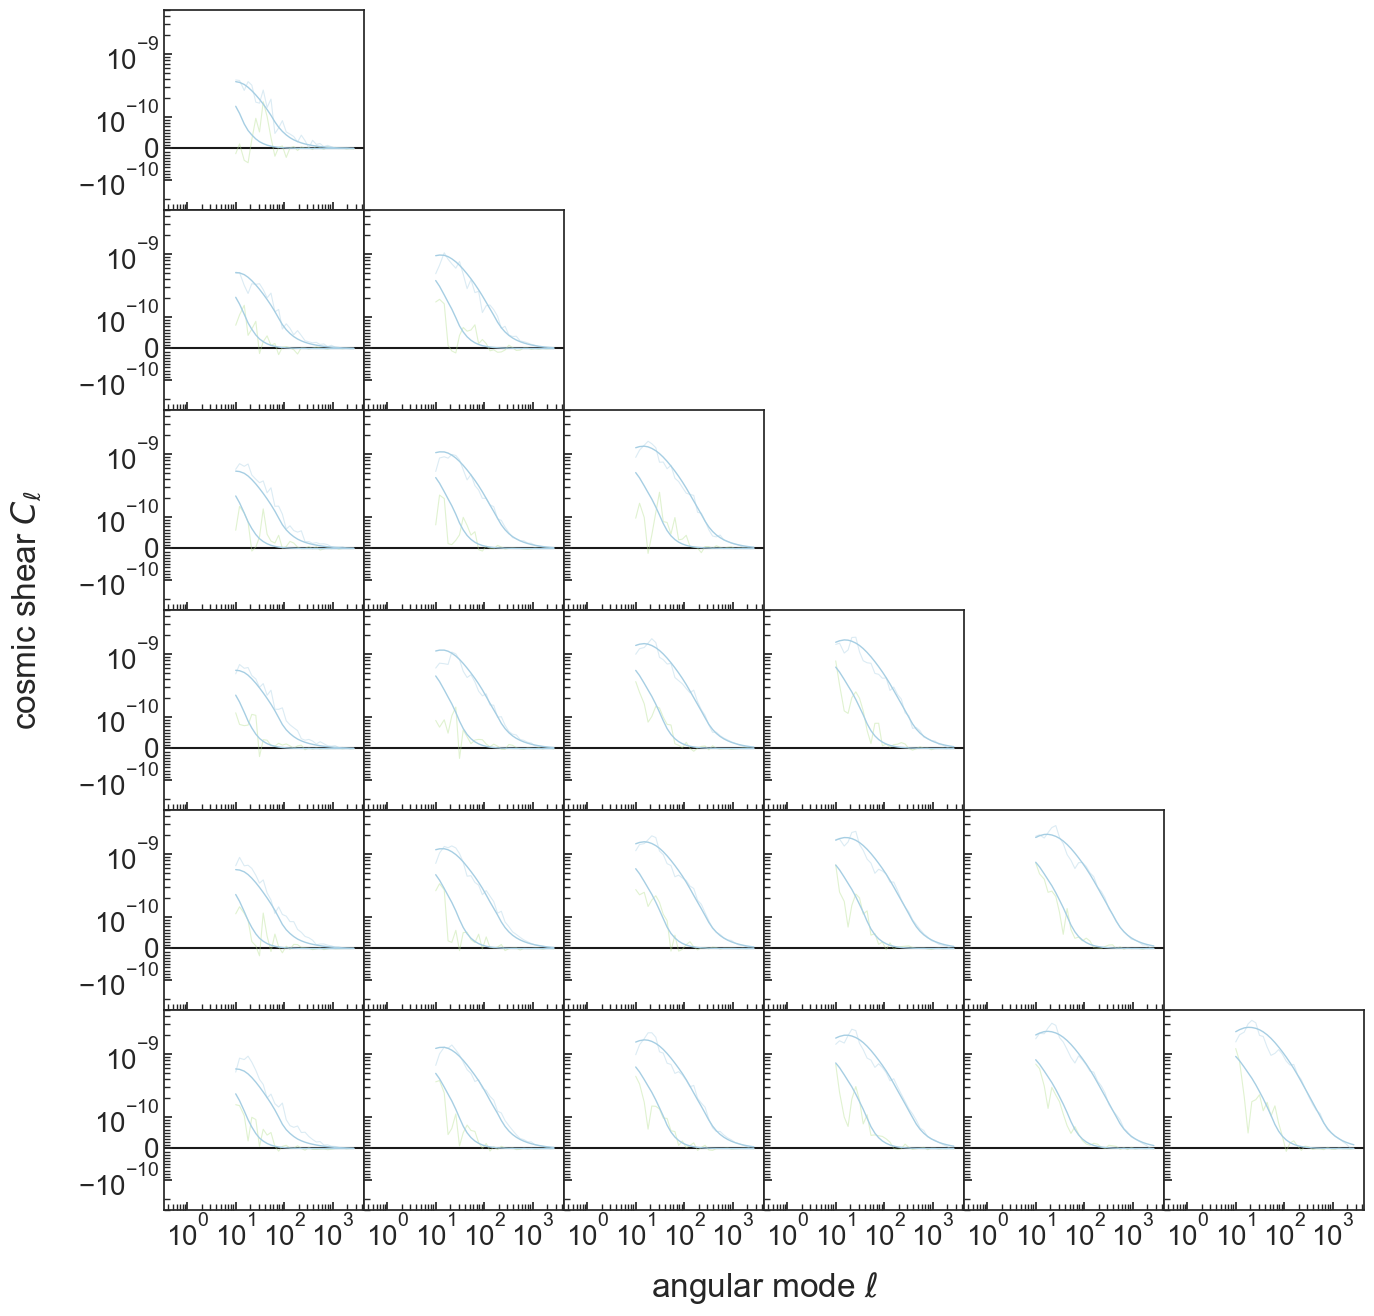

In [15]:
fig, ax = plt.subplots(6, 6, figsize=(12, 12), sharex=True, sharey=True)

for i in range(1, 7):
    for j in range(1, i):
        ax[j - 1, i - 1].axis("off")
    for j in range(i, 7):
        ax[j - 1, i - 1].plot(
            cls_example["SHE", "SHE",i, j].ell,
            cls_example["SHE", "SHE",i, j][0, 0],
            c="C0",
            lw=0.8,
            zorder=3.0,
            alpha=0.4,
        )
        ax[j - 1, i - 1].plot(
            cells_SS["SHE", "SHE",i, j].ell, cells_SS["SHE", "SHE",i, j][0, 0], c="C0", lw=1.0, zorder=4.0
        )
        ax[j - 1, i - 1].plot(
            cls_example["SHE", "SHE",i, j].ell,
            cls_example["SHE", "SHE",i, j][1, 1],
            c="C2",
            lw=0.8,
            zorder=1.0,
            alpha=0.4,
        )
        ax[j - 1, i - 1].plot(
            cells_SS["SHE", "SHE",i, j].ell, cells_SS["SHE", "SHE",i, j][1, 1], c="C0", lw=1.0, zorder=4.0
        )
        ax[j - 1, i - 1].axhline(0.0, c="k", lw=1.5, zorder=-1)
        ax[j - 1, i - 1].tick_params(axis="both", which="both", direction="in")

ax[0, 0].set_xscale("log")
ax[0, 0].set_xlim(1 / 3, 1500 * 3)
ax[0, 0].xaxis.get_major_locator().set_params(numticks=99)
ax[0, 0].xaxis.get_minor_locator().set_params(
    numticks=99, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_yscale(
    "symlog", linthresh=1e-10, linscale=0.45, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_ylim(-3e-10, 5e-9)

fig.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0, wspace=0.0, hspace=0.0)

fig.supxlabel("angular mode $\\ell$", y=-0.05, va="top")
fig.supylabel("cosmic shear $C_\\ell$", x=-0.1, ha="right")

plt.show()

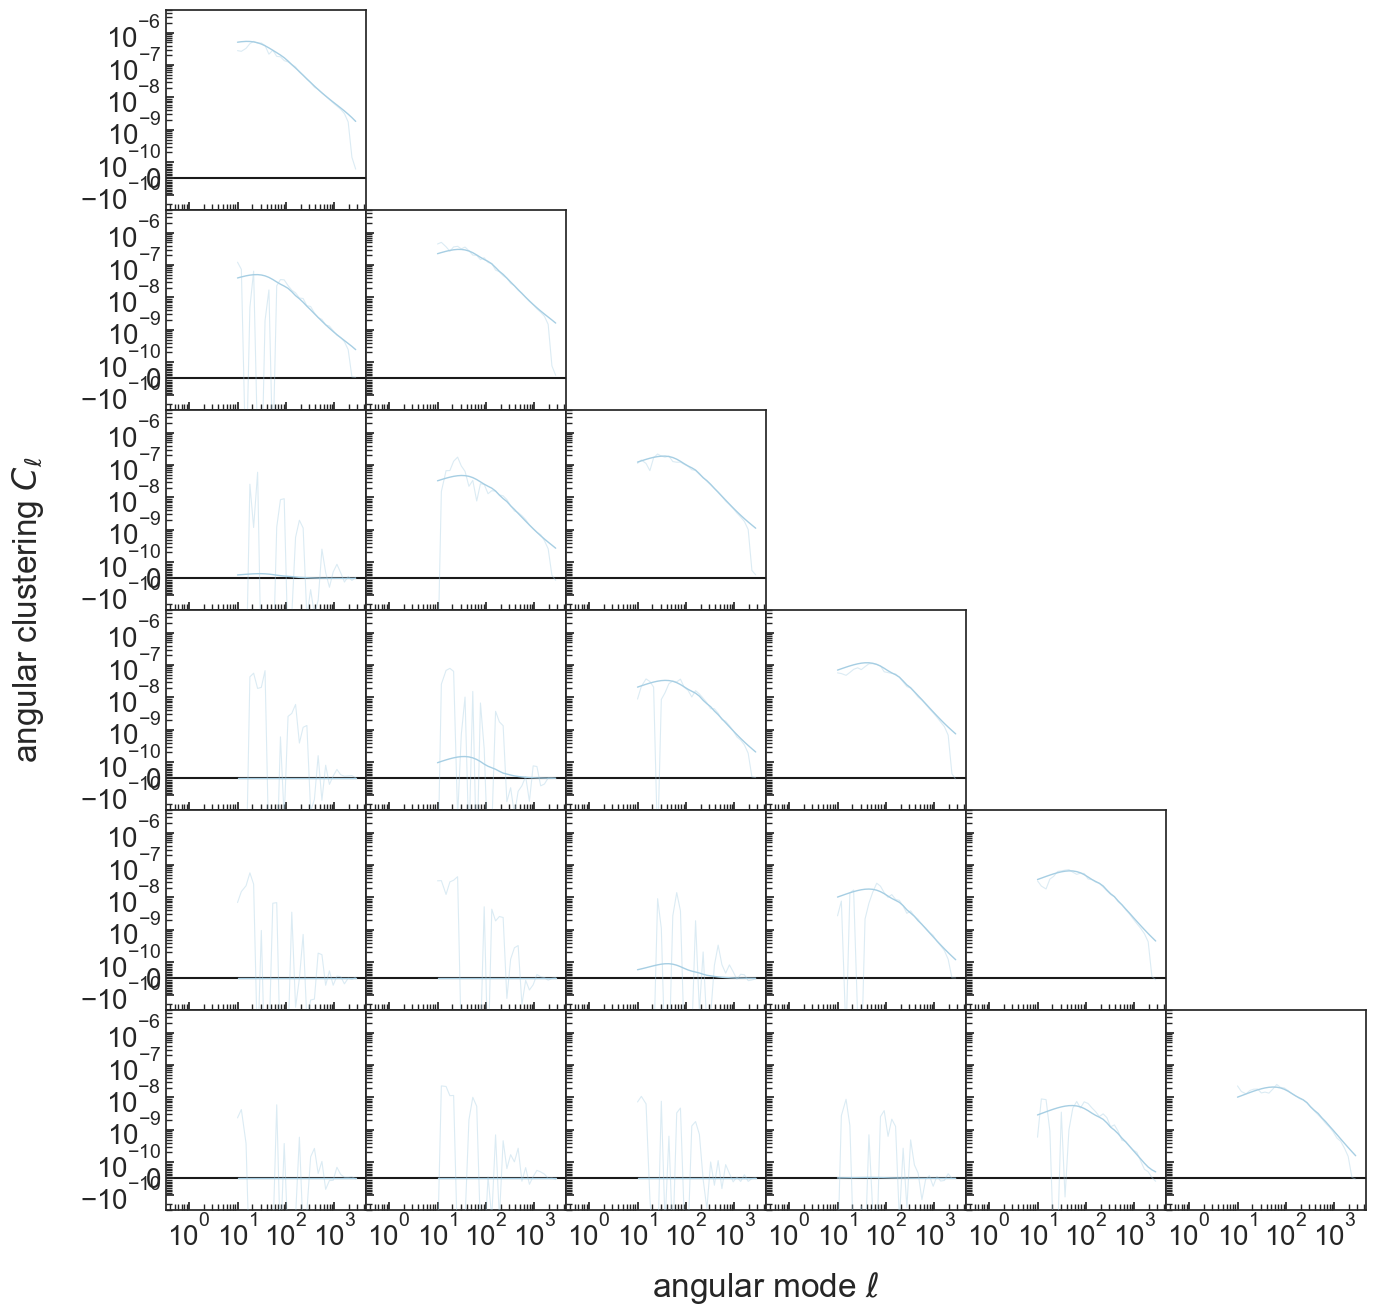

In [16]:
fig, ax = plt.subplots(6, 6, figsize=(12, 12), sharex=True, sharey=True)

for i in range(1, 7):
    for j in range(1, i):
        ax[j - 1, i - 1].axis("off")
    for j in range(i, 7):
        ax[j - 1, i - 1].plot(
            cls_example["POS", "POS",i, j].ell,
            cls_example["POS", "POS",i, j],
            c="C0",
            lw=0.8,
            zorder=3.0,
            alpha=0.4,
        )
        ax[j - 1, i - 1].plot(
            cells_PP["POS", "POS",i, j].ell, cells_PP["POS", "POS",i, j], c="C0", lw=1.0, zorder=4.0
        )
        ax[j - 1, i - 1].axhline(0.0, c="k", lw=1.5, zorder=-1)
        ax[j - 1, i - 1].tick_params(axis="both", which="both", direction="in")

ax[0, 0].set_xscale("log")
ax[0, 0].set_xlim(1 / 3, 1500 * 3)
ax[0, 0].xaxis.get_major_locator().set_params(numticks=99)
ax[0, 0].xaxis.get_minor_locator().set_params(
    numticks=99, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_yscale(
    "symlog", linthresh=1e-10, linscale=0.45, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_ylim(-3e-10, 5e-6)

fig.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0, wspace=0.0, hspace=0.0)

fig.supxlabel("angular mode $\\ell$", y=-0.05, va="top")
fig.supylabel("angular clustering $C_\\ell$", x=-0.1, ha="right")

plt.show()

## Angular correlation functions

We compute the angular correlation functions ($\xi$) from the $C(\ell)$. The calculation automatically calculates the correlation function for all tomo bin combinations at with $C(\ell)$ is defined.

In [17]:
# Define at which theta to evaluate the correlation function

theta_deg = np.geomspace(5, 100, 20)/60 # in degrees

theta_rad = np.deg2rad(theta_deg)  # in radians


We first calculate the position-position correlation function and plot the auto-correlations

In [18]:
# Position-Position correlation function

ells_integration = np.arange(2, 60000)  # Multipole moments over which to integrate

# Initialize correlation function calculation object
correlation_function_GG = AngularCorrelationFunctionWigner(twopoint_pospos, ells_integration, perturbations.k)

# Get correlation function at the defined thetas (NOTE: this takes the separation in radians!)
xi_pospos = correlation_function_GG.get_xi(theta_rad)


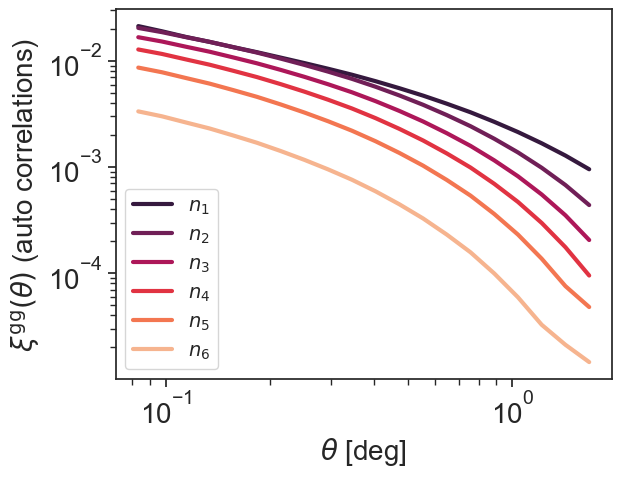

In [19]:
# plot

fig, ax = plt.subplots()


for i, color in zip(range(0, 6), sns.color_palette("rocket", len(dndz_pos_norm))):
    ax.loglog(theta_deg, xi_pospos[:, i, i], c=color,
              label=f"$n_{i+1}$")
    
ax.set_xlabel(r'$\theta$ [deg]')
ax.set_ylabel(r'$\xi^{\rm gg}(\theta)$ (auto correlations)')

ax.legend()


Next we calculate the shear-position correlation functions

In [20]:
ells_integration = np.arange(2, 60000)  # Multipole moments over which to integrate

# Initialize correlation function calculation object
correlation_function_EG = AngularCorrelationFunctionWigner(twopoint_shepos, ells_integration, perturbations.k)

# Get correlation function at the defined thetas (NOTE: this takes the separation in radians!)
xi_shepos = correlation_function_EG.get_xi(theta_rad)


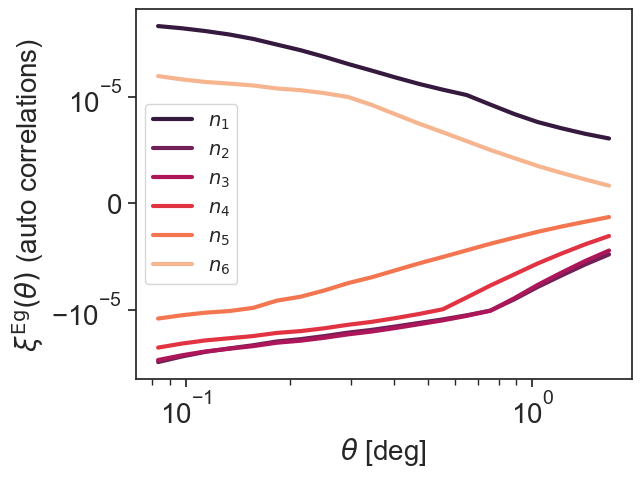

In [21]:
# plot

fig, ax = plt.subplots()


for i, color in zip(range(0, 6), sns.color_palette("rocket", len(dndz_pos_norm))):
    ax.loglog(theta_deg, xi_shepos[:, i, i], c=color,
              label=f"$n_{i+1}$")
    
ax.set_xlabel(r'$\theta$ [deg]')
ax.set_ylabel(r'$\xi^{\rm Eg}(\theta)$ (auto correlations)')
# Set y-axis to symmetric log scale to handle negative values
ax.set_yscale('symlog', linthresh=1e-5)
ax.legend()


Finally, we calculate the shear-shear correlation functions. Note that the object automatically gives both $\xi_+$ and $\xi_-$ if $C(\ell)$ of two spin-2 tracers are given.

In [22]:
ells_integration = np.arange(2, 30000)  # Multipole moments over which to integrate

# Initialize correlation function calculation object
correlation_function_EE = AngularCorrelationFunctionWigner(twopoint_sheshe, ells_integration, perturbations.k)


# Get correlation function at the defined thetas (NOTE: this takes the separation in radians!)
xi_sheshe_plus, xi_sheshe_minus = correlation_function_EE.get_xi(theta_rad)



In [ ]:
# plot

fig, ax = plt.subplots()


for i, color in zip(range(0, 6), sns.color_palette("mako", len(dndz_she_norm))):
    ax.loglog(theta_deg, xi_sheshe_plus[:, i, i], c=color,
              label=f"$n_{i+1}$")
    
ax.set_xlabel(r'$\theta$ [deg]')
ax.set_ylabel(r'$\xi^{\rm EE}_+(\theta)$ (auto correlations)')

ax.legend()


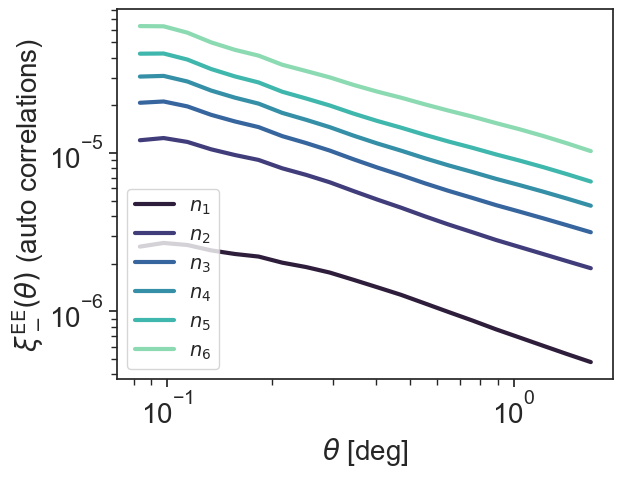

In [ ]:
# plot

fig, ax = plt.subplots()


for i, color in zip(range(0, 6), sns.color_palette("mako", len(dndz_she_norm))):
    ax.loglog(theta_deg, xi_sheshe_minus[:, i, i], c=color,
              label=f"$n_{i+1}$")
    
ax.set_xlabel(r'$\theta$ [deg]')
ax.set_ylabel(r'$\xi^{\rm EE}_-(\theta)$ (auto correlations)')

ax.legend()
